# Module 10 — Main Pipeline (End-to-End Runner)


```
Step 1 → Train CNN (or load saved weights)
Step 2 → Load test image
Step 3 → Run CNN + Fuzzy enhancement
Step 4 → Run Fuzzy-only enhancement (baseline)
Step 5 → Evaluate with PSNR + SSIM
Step 6 → Generate all visualisation figures
```


In [13]:
# User settings

IMAGE_PATH   = "sample.png"     # path to YOUR image (or leave as-is for synthetic)
RETRAIN      = False            # set True to retrain from scratch
NUM_SAMPLES  = 6000             # training samples (increase for better accuracy)

print("Settings:")
print(f"  Image path  : {IMAGE_PATH}")
print(f"  Retrain     : {RETRAIN}")
print(f"  Num samples : {NUM_SAMPLES}")

Settings:
  Image path  : sample.png
  Retrain     : False
  Num samples : 6000


In [ ]:
# Imports 

import os
import sys
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

from config            import Config
from feature_extractor import extract_features, features_to_vector
from cnn_model         import EnhancementCNN
from dataset           import SyntheticEnhancementDataset, compute_ideal_params
from fuzzy_system      import FuzzyEnhancementSystem, adjustment_mf_vec
from enhancer          import ImageEnhancer, apply_enhancement
from evaluator         import evaluate_enhancement, compute_psnr, compute_ssim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"All modules imported.")
print(f"   Device: {DEVICE}")

All modules imported.
   Device: cpu


In [ ]:
#Step 1: Train or load the CNN

def train_cnn(num_samples: int) -> EnhancementCNN:
    """Full training pipeline (extracted here for self-contained main notebook)."""
    full_ds  = SyntheticEnhancementDataset(num_samples=num_samples)
    val_size = int(0.15 * num_samples)
    trn_size = num_samples - val_size
    train_ds, val_ds = torch.utils.data.random_split(full_ds, [trn_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False)

    model     = EnhancementCNN().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=Config.LEARNING_RATE,
                                   weight_decay=Config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=Config.NUM_EPOCHS, eta_min=1e-5)

    history = {"train": [], "val": []}
    best_val = float("inf")

    for epoch in range(1, Config.NUM_EPOCHS + 1):
        model.train()
        tloss = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tloss.append(loss.item())

        model.eval()
        vloss = []
        with torch.no_grad():
            for xb, yb in val_loader:
                vloss.append(criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item())

        avg_t, avg_v = np.mean(tloss), np.mean(vloss)
        scheduler.step()
        history["train"].append(avg_t)
        history["val"].append(avg_v)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{Config.NUM_EPOCHS}  "
                  f"train={avg_t:.5f}  val={avg_v:.5f}")

        if avg_v < best_val:
            best_val = avg_v
            torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)

    print(f"\nTraining done.  Best val loss: {best_val:.5f}")
    model.load_state_dict(torch.load(Config.MODEL_SAVE_PATH, map_location="cpu"))
    model.eval()

    # Loss curve
    plt.figure(figsize=(8, 3))
    plt.plot(history["train"], label="Train")
    plt.plot(history["val"],   label="Val", linestyle="--")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title("Training loss curve"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig("training_loss.png", dpi=120); plt.show()

    return model


if RETRAIN or not os.path.exists(Config.MODEL_SAVE_PATH):
    print("[Step 1] Training CNN...")
    _ = train_cnn(NUM_SAMPLES)
else:
    print(f"[Step 1] Found saved model at '{Config.MODEL_SAVE_PATH}'. Skipping training.")
    print("         (Set RETRAIN = True in cell 1 to retrain from scratch.)")

[Step 1] Found saved model at 'cnn_enhancer.pth'. Skipping training.
         (Set RETRAIN = True in cell 1 to retrain from scratch.)


In [ ]:
# Step 2: Load test image 

print("[Step 2] Loading image...")

if os.path.exists(IMAGE_PATH):
    original = cv2.imread(IMAGE_PATH)
    original = cv2.resize(original, Config.IMAGE_SIZE)
    print(f"  Loaded '{IMAGE_PATH}'  shape={original.shape}")
else:
    print(f"  '{IMAGE_PATH}' not found. Generating synthetic dark image.")
    np.random.seed(42)
    base     = np.random.randint(15, 80, (*Config.IMAGE_SIZE, 3), dtype=np.uint8)
    original = cv2.GaussianBlur(base, (9, 9), 0)
    cv2.imwrite(IMAGE_PATH, original)
    print(f"  Synthetic image saved to '{IMAGE_PATH}'")

gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY) if original.ndim == 3 else original
print(f"  Mean intensity: {gray.mean()/255:.3f}  Std: {gray.std()/255:.3f}")

[Step 2] Loading image...
  Loaded 'sample.png'  shape=(128, 128, 3)
  Mean intensity: 0.057  Std: 0.029


In [ ]:
# Step 3 & 4: Run both enhancement modes

print("[Step 3] Running CNN + Fuzzy enhancement...")
enhancer         = ImageEnhancer(model_path=Config.MODEL_SAVE_PATH)
cnn_fuzzy_img, info  = enhancer.enhance(original)

print("[Step 4] Running Fuzzy-only enhancement (baseline)...")
fuzzy_only_img, _    = enhancer.enhance_fuzzy_only(original)

print("\n── Enhancement parameters ──")
print(f"  Brightness factor  : {info['brightness_factor']:.4f}")
print(f"  Contrast factor    : {info['contrast_factor']:.4f}")
print(f"  Gamma              : {info['gamma']:.4f}")
print(f"  Fuzzy adjustment   : {info['fuzzy_adjustment']:.4f}")
print(f"  Fuzzy scale        : {info['fuzzy_scale']:.4f}")

[Step 3] Running CNN + Fuzzy enhancement...
[Enhancer] CNN loaded from 'cnn_enhancer.pth'
[Enhancer] Fuzzy system initialised.
[Step 4] Running Fuzzy-only enhancement (baseline)...

── Enhancement parameters ──
  Brightness factor  : 2.0000
  Contrast factor    : 2.0000
  Gamma              : 0.8569
  Fuzzy adjustment   : 0.5000
  Fuzzy scale        : 1.2500


In [7]:
# ── Step 5: Evaluate ──────────────────────────────────────────────────────────

print("[Step 5] Computing evaluation metrics...")
metrics = evaluate_enhancement(original, fuzzy_only_img, cnn_fuzzy_img)

[Step 5] Computing evaluation metrics...
IMAGE ENHANCEMENT EVALUATION Method │  PSNR (dB) │ SSIMFuzzy only  24.263 | 0.73505CNN + Fuzzy  14.064 | 0.37393Best PSNR: Fuzzy onlyBest SSIM: Fuzzy only


[Step 6] Generating visualisations...


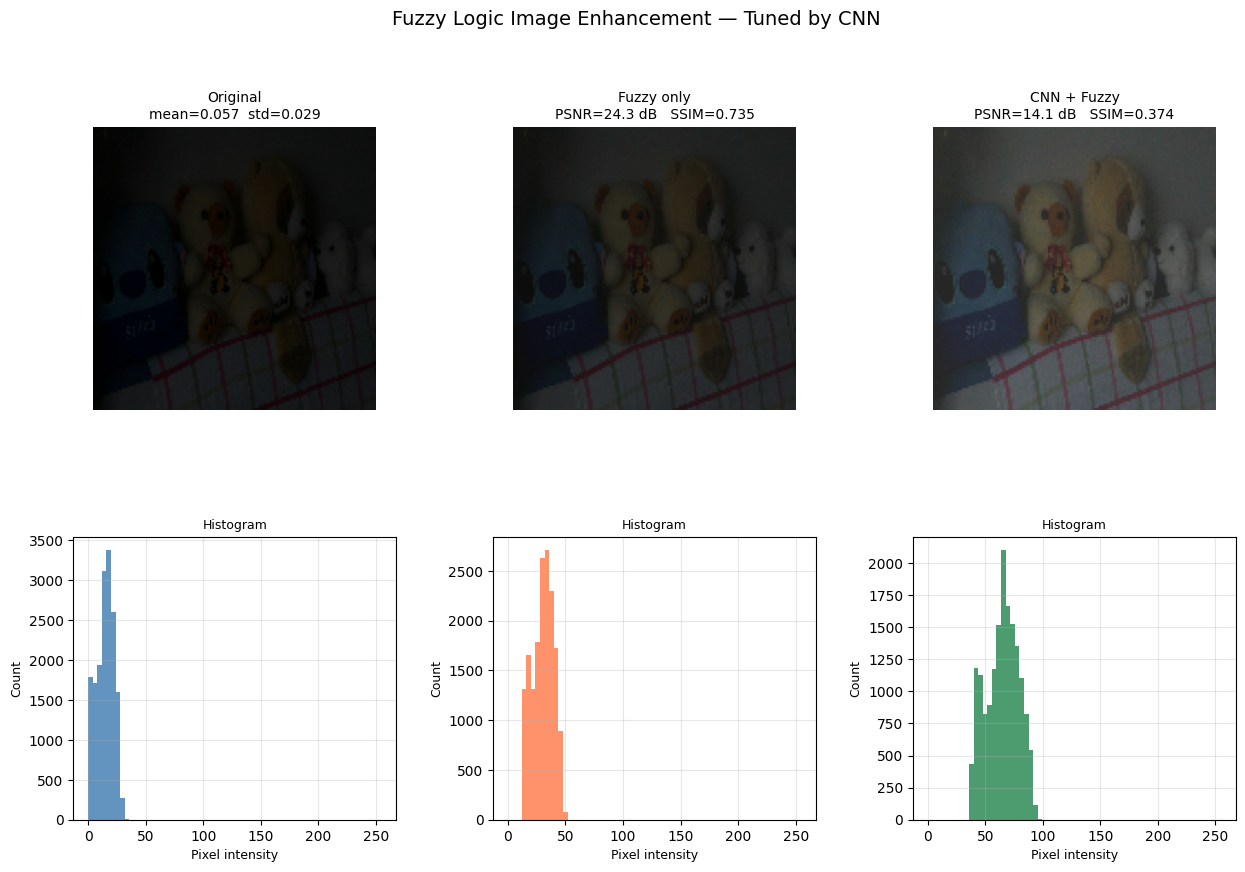

✅ Saved results.png


In [ ]:
#step 6: Full results figure

print("[Step 6] Generating visualisations...")

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

images      = [original,      fuzzy_only_img,    cnn_fuzzy_img]
titles      = ["Original",    "Fuzzy only",      "CNN + Fuzzy"]
hist_colors = ["steelblue",   "coral",           "seagreen"]
metric_lbls = [
    f"mean={gray.mean()/255:.3f}  std={gray.std()/255:.3f}",
    f"PSNR={metrics['psnr_fuzzy']:.1f} dB   SSIM={metrics['ssim_fuzzy']:.3f}",
    f"PSNR={metrics['psnr_cnn']:.1f} dB   SSIM={metrics['ssim_cnn']:.3f}",
]

for col, (img, title, color, mlbl) in enumerate(
        zip(images, titles, hist_colors, metric_lbls)):
    ax_img = fig.add_subplot(gs[0, col])
    disp   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    ax_img.imshow(disp, cmap="gray" if img.ndim == 2 else None)
    ax_img.set_title(f"{title}\n{mlbl}", fontsize=10)
    ax_img.axis("off")

    ax_hist = fig.add_subplot(gs[1, col])
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    ax_hist.hist(g.ravel(), bins=64, range=(0,255),
                 color=color, alpha=0.85, edgecolor="none")
    ax_hist.set_xlabel("Pixel intensity", fontsize=9)
    ax_hist.set_ylabel("Count",           fontsize=9)
    ax_hist.set_title("Histogram",        fontsize=9)
    ax_hist.grid(alpha=0.3)

fig.suptitle("Fuzzy Logic Image Enhancement — Tuned by CNN", fontsize=14, y=1.01)
plt.savefig("results.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved results.png")

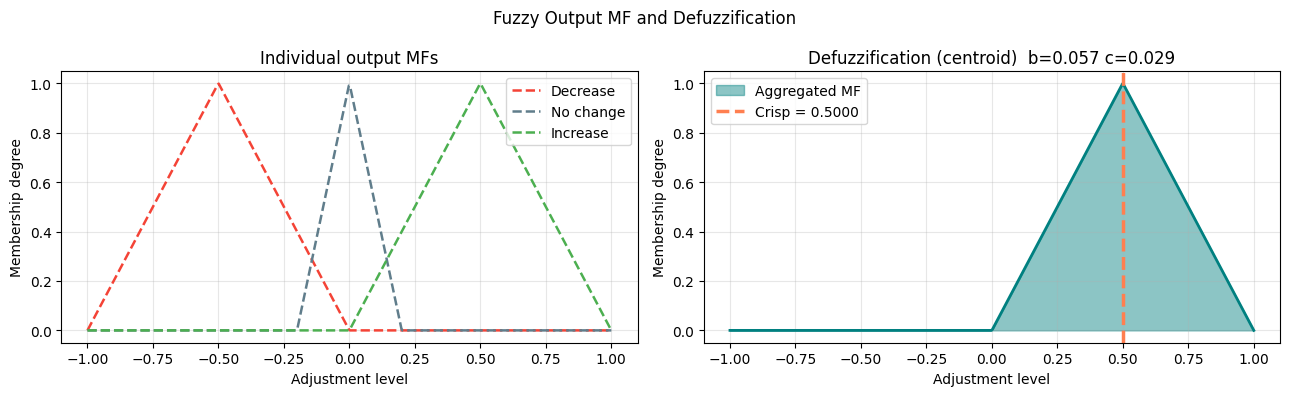

✅ Saved fuzzy_output_mf.png


In [ ]:
# ── Step 6b: Fuzzy output MF figure ──────────────────────────────────────────

fis    = FuzzyEnhancementSystem()
x_out  = fis.get_universe()
result = fis.infer(info["features"]["mean"], info["features"]["std"])
agg    = result["aggregated"]
crisp  = result["adjustment"]

dec = adjustment_mf_vec(x_out, "decrease")
nc  = adjustment_mf_vec(x_out, "no_change")
inc = adjustment_mf_vec(x_out, "increase")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for vals, lbl, col in [(dec,"Decrease","#F44336"),(nc,"No change","#607D8B"),(inc,"Increase","#4CAF50")]:
    ax1.plot(x_out, vals, "--", color=col, label=lbl, linewidth=1.8)
ax1.set_title("Individual output MFs"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_xlabel("Adjustment level"); ax1.set_ylabel("Membership degree")

ax2.fill_between(x_out, agg, alpha=0.45, color="teal", label="Aggregated MF")
ax2.plot(x_out, agg, color="teal", linewidth=2)
ax2.axvline(crisp, color="coral", linewidth=2.5, linestyle="--",
            label=f"Crisp = {crisp:.4f}")
ax2.set_title(f"Defuzzification (centroid)  b={info['features']['mean']:.3f} c={info['features']['std']:.3f}")
ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_xlabel("Adjustment level"); ax2.set_ylabel("Membership degree")

plt.suptitle("Fuzzy Output MF and Defuzzification", fontsize=12)
plt.tight_layout()
plt.savefig("fuzzy_output_mf.png", dpi=120)
plt.show()
print("Saved fuzzy_output_mf.png")

In [12]:
# ── Final summary ─────────────────────────────────────────────────────────────



print(f"  PSNR (Fuzzy only) : {metrics['psnr_fuzzy']:.2f} dB")
print(f"  PSNR (CNN+Fuzzy)  : {metrics['psnr_cnn']:.2f} dB")
print(f"  SSIM (Fuzzy only) : {metrics['ssim_fuzzy']:.4f}")
print(f"  SSIM (CNN+Fuzzy)  : {metrics['ssim_cnn']:.4f}")

  PSNR (Fuzzy only) : 24.26 dB
  PSNR (CNN+Fuzzy)  : 14.06 dB
  SSIM (Fuzzy only) : 0.7350
  SSIM (CNN+Fuzzy)  : 0.3739
